# Introduction to Plotting


> Adapted from [DartBrains](https://dartbrains.org/) by Luke Chang (© Luke Chang, supported by NSF CAREER Award 1848370), used under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). **Changes made:** trimmed to the exercise sections, setup code reduced to the cells the exercises depend on, display-only calls removed. Exercise solutions are my own work. This notebook is therefore also distributed under CC BY-SA 4.0. No endorsement by the original author is implied.


## Setup


In [ ]:
%matplotlib inline
pass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exercises
The following exercises uses the dataset "salary_exercise.csv" adapted from material available [here](http://data.princeton.edu/wws509/datasets/#salary)

These are the salary data used in Weisberg's book, consisting of observations on six variables for 52 tenure-track professors in a small college. The variables are:

 - sx = Sex, coded 1 for female and 0 for male
 - rk = Rank, coded
 - 1 for assistant professor,
 - 2 for associate professor, and
 - 3 for full professor
 - yr = Number of years in current rank
 - dg = Highest degree, coded 1 if doctorate, 0 if masters
 - yd = Number of years since highest degree was earned
 - sl = Academic year salary, in dollars.

Reference: S. Weisberg (1985). Applied Linear Regression, Second Edition. New York: John Wiley and Sons. Page 194.


### Exercise 1
Recreate the plot shown in the figure below.
On the left is a correlation of three parameters of only the male professors.  
On the right is the same but only for female professors.   
The colormap code used is `RdBu_r`. Read the Docstrings on sns.heatmap or search the internet to figure out how to change the colormap, scale the colorbar, and create square line boundaries.   
Place titles for each plot as shown, and your name as the main title.   

<!-- ![](../images/plotting/hw2-3.png) -->
![](hw2-3.png)

       sx    rk  yr         dg  yd       sl
0    male  full  25  doctorate  35  36350.0
1    male  full  13  doctorate  22  35350.0
2    male  full  10  doctorate  23  28200.0
3  female  full   7  doctorate  27  26775.0
4    male  full  19    masters  30  33696.0
       sx    rk  yearsinrank         dg  yearssinceHD   salary
0    male  full           25  doctorate            35  36350.0
1    male  full           13  doctorate            22  35350.0
2    male  full           10  doctorate            23  28200.0
3  female  full            7  doctorate            27  26775.0
4    male  full           19    masters            30  33696.0
              yearsinrank  yearssinceHD    salary
yearsinrank      1.000000      0.775124  0.734247
yearssinceHD     0.775124      1.000000  0.709632
salary           0.734247      0.709632  1.000000
              yearsinrank  yearssinceHD    salary
yearsinrank      1.000000      0.418074  0.487078
yearssinceHD     0.418074      1.000000  0.635110
salary  

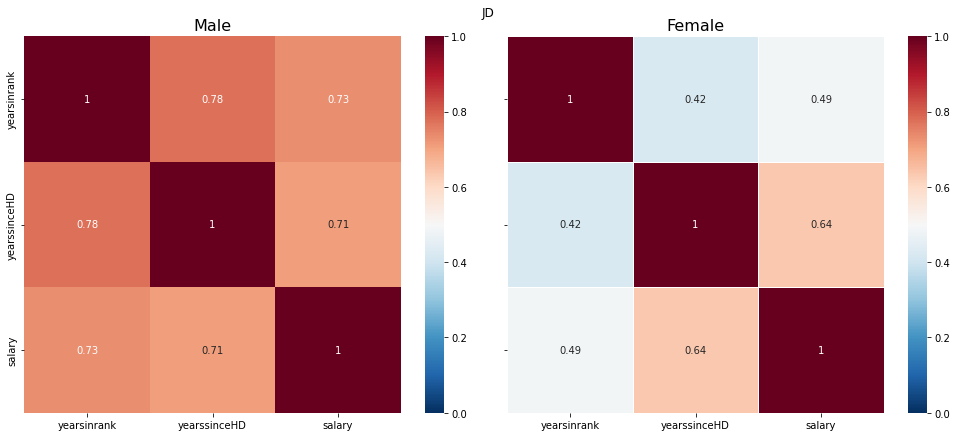

In [ ]:
# load and check out our dataframe
salary_file_url = 'https://raw.githubusercontent.com/ljchang/dartbrains/master/data/salary/salary_exercise.csv'
sData = pd.read_csv(salary_file_url)
print(sData.head())

# rename some variables per the example plots
sData = sData.rename(columns={'yr':'yearsinrank','yd':'yearssinceHD','sl':'salary'})
print(sData.head())

# make sex-specific dataframes
m_salaries = sData[sData['sx'] == 'male']
f_salaries = sData[sData['sx'] == 'female']

# start with the male salaries
m_corr = m_salaries.loc[:,['yearsinrank','yearssinceHD','salary']].corr()

# cross reference one of the correlation matrices with the example figure
m_corr # the numbers look a little different from what's in the example... let's investigate...

# let's check out the male salaries dataframe
m_salaries # maybe rows with nan values were removed before generating the example plots??

# remove rows with NaN values and recompute the correlation matrix
m_salaries = m_salaries[~m_salaries.isnull().any(axis=1)]
m_corr = m_salaries.loc[:,['yearsinrank','yearssinceHD','salary']].corr()
print(m_corr) # the recomputed correlation values match the example figure! yay!

# do same for the female salaries
f_salaries = f_salaries[~f_salaries.isnull().any(axis=1)]
f_corr = f_salaries.loc[:,['yearsinrank','yearssinceHD','salary']].corr()
print(f_corr) # yay

# recreate the figure
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)
f.suptitle('JD')
sns.heatmap(m_corr, square=True, annot=True, cmap='RdBu_r', vmin=0, vmax=1, ax=ax[0])
sns.heatmap(f_corr, square=True, annot=True, linewidths=.5, cmap='RdBu_r', vmin=0, vmax=1, ax=ax[1])
ax[0].set_title('Male', fontsize=16)
ax[1].set_title('Female', fontsize=16)
plt.tight_layout()

### Exercise 2
Recreate the following plot from the salary_exercise.csv dataset.   
Create a 1 x 2 subplot.   
On the left is a bar-errorbar of salary per gender.   
On the right is a scatterplot of salary on y-axis and years in rank on the x-axis.  
Set the axis limits as shown in the picture and modify their labels.
Add axis label names.   
Add a legend for the scatterplot and place it at a bottom-right location.  
Add your name as the main title of the plot.   

<!-- ![](../images/plotting/hw2-4.png) -->
![](hw2-4.png)

Text(0.5, 0.98, 'JD')

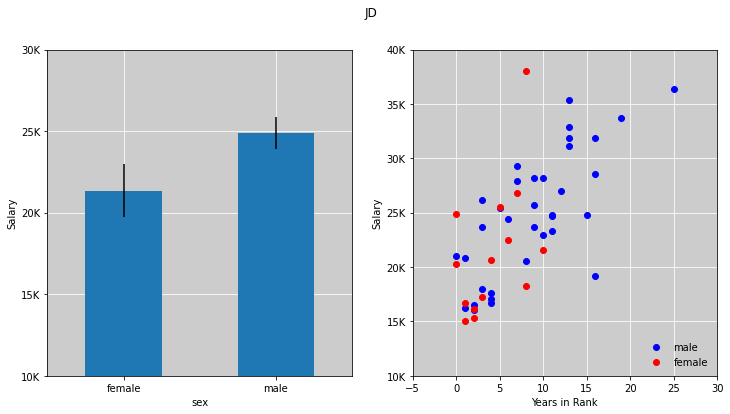

In [ ]:
# initialize the figure
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# get salary means and standard errors for the bar plot
# we could do this with the sex-specific dataframes we generated in Exercise 1...
means = pd.DataFrame([f_salaries.mean()['salary'], m_salaries.mean()['salary']])
errors = pd.DataFrame([f_salaries.std()['salary'] / np.sqrt(f_salaries.count()['salary']), m_salaries.std()['salary'] / np.sqrt(m_salaries.count()['salary'])]) # standard error = std / sqrt(n)

# but that code is pretty cumbersome... let's clean up the original dataset and use the df.groupby() function
data = sData[~sData.isnull().any(axis=1)] # remove rows with missing data values
means = data.groupby('sx').mean()['salary']
errors = data.groupby('sx').std()['salary'] / np.sqrt(data.groupby('sx').count()['salary'])

# make the bar plot
means.plot.bar(yerr=errors,ylabel='Salary', ax=ax[0], zorder=2)
ax[0].set_yticks([10000, 15000, 20000, 25000, 30000])
ax[0].set_yticklabels(['10K', '15K', '20K', '25K', '30K'])
ax[0].set_ylim(bottom=10000, top=30000)
ax[0].set_xticklabels(['female','male'], rotation = 0)
ax[0].set_xlabel('sex')
ax[0].set_facecolor((.8,.8,.8))
ax[0].grid(zorder=0,color='white')

# make the scatter plot - let's use our sex-specific dataframes from Exercise 1
ax[1].scatter(m_salaries['yearsinrank'],m_salaries['salary'],color='blue',label='male', zorder=2)
ax[1].scatter(f_salaries['yearsinrank'],f_salaries['salary'],color='red',label='female', zorder=2)
ax[1].set_facecolor((.8,.8,.8))
ax[1].grid(zorder=0,color='white')
ax[1].set_xticks(np.arange(-5,31,5))
ax[1].set_xlabel('Years in Rank')
ax[1].set_ylabel('Salary')
ax[1].set_yticks(np.arange(10000,40001,5000))
ax[1].set_yticklabels(['10K', '15K', '20K', '25K', '30K', '35K', '40K'])
ax[1].set_ylim(bottom=10000, top=40000)
ax[1].legend(loc='lower right', frameon=False)

# add name
f.suptitle('JD')